# Exercício 1: Union 2.1 for supernovae

$E^2(z)=\Omega_m(1+z)^3+\Omega_\Lambda+\Omega_k(1+z)^2$

Objetivo: A partir das 580 supernovas observadas, dizer qual é o $\Omega_m$ e o $\Omega_\Lambda$ do universo e qual é a confiança que se tem nesses valores.

A cosmologia, o MCMC, os dados, a verossimilhança, a priori e os diagnósticos estão na biblioteca `cosmonum`. Os testes de cada peça ficam em `tests/` e rodam com `pytest`; aqui fica só a análise.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.linalg import solve_triangular
from scipy.ndimage import gaussian_filter

from cosmonum.cosmology import FLRW
from cosmonum.bayes import Posterior, GaussianRandomWalk, MetropolisHastings
from cosmonum.union21 import (z_sn, mu_obs, sigma_mu, cov_sys, L_sys, chi2_marg,
                              log_likelihood, log_prior, OM_MIN, OM_MAX, OL_MIN, OL_MAX)
from cosmonum.diagnostics import (taxa_movel, autocorrelacao, tempo_autocorrelacao,
                                  ess, mcse, split_rhat, espectro, dunkley)

FIGURAS = Path("figuras")
FIGURAS.mkdir(exist_ok=True)

## Dados e posterior

In [2]:
# a tabela dada pela colaboração vem em colunas com o nome da supernova, redshift, módulo de distancia e erro no módulo de distancia.
print("numero de supernovas:", len(z_sn))
print("faixa de z:", z_sn.min(), "a", z_sn.max())
print("tamanho da covariancia:", cov_sys.shape)

post = Posterior(FLRW, log_likelihood, log_prior)
print("chi2 em (0.29, 0.68):", chi2_marg(FLRW(70, 0.29, 0.68).mu(z_sn)))
print("log posterior em (0.29, 0.68):", post((0.29, 0.68)))

numero de supernovas: 580
faixa de z: 0.015 a 1.414
tamanho da covariancia: (580, 580)
chi2 em (0.29, 0.68): 545.1280246701148
log posterior em (0.29, 0.68): -272.5640123350574


fracao sem Big Bang: 0.14117015566290927  distancia invalida: 0.015873015873015872


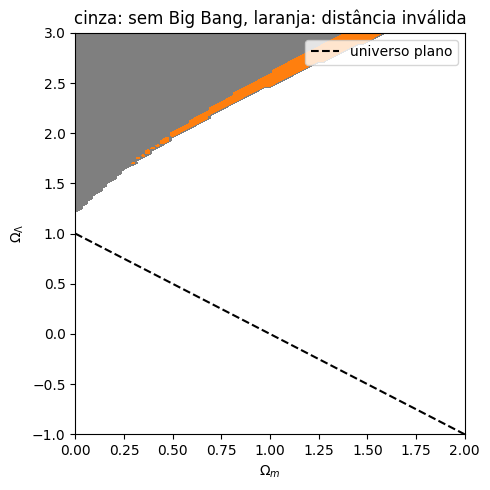

In [3]:
# onde a posterior e zero dentro da caixa da priori
Oms = np.linspace(OM_MIN, OM_MAX, 81)
OLs = np.linspace(OL_MIN, OL_MAX, 161)
mapa = np.zeros((len(Oms), len(OLs)))          # 0 valido, 1 sem Big Bang, 2 distancia invalida
for i, Om in enumerate(Oms):
    for j, OL in enumerate(OLs):
        if log_prior((Om, OL)) == -np.inf:
            mapa[i, j] = 1
        elif log_likelihood((Om, OL), FLRW) == -np.inf:
            mapa[i, j] = 2
print("fracao sem Big Bang:", np.mean(mapa == 1), " distancia invalida:", np.mean(mapa == 2))

plt.figure(figsize=(5, 5))
plt.contourf(Oms, OLs, mapa.T, levels=[-0.5, 0.5, 1.5, 2.5],colors=["white", "tab:gray", "tab:orange"])
plt.plot([0, 2], [1, -1], "k--", label="universo plano")
plt.xlabel(r"$\Omega_m$"); plt.ylabel(r"$\Omega_\Lambda$")
plt.title("cinza: sem Big Bang, laranja: distância inválida")
plt.legend(); plt.tight_layout(); plt.savefig(FIGURAS / "priori.png", dpi=150); plt.show()

## Cadeias

In [4]:
Seed = 20260913
N_cadeias = 4
N_passos = 50_000

geradores = [np.random.default_rng(s) for s in np.random.SeedSequence(Seed).spawn(N_cadeias + 2)]
rng_aquecimento = geradores[0]
rng_inicios = geradores[1]
rngs_cadeias = geradores[2:]

#descobrir o tamanho e a inclinação da posterior
cov_prop= np.diag([0.05**2,0.05**2]) #palpite, passos de 0.05 sem inclinação.
theta = [0.3, 0.7] #palpite inicial
for rodada in range(2):
    mh = MetropolisHastings(post, GaussianRandomWalk(cov_prop))
    amostras_aq, _, _, taxa_aq = mh.sample(theta, 5_000, rng_aquecimento)
    cov_prop = 2.38**2/2 * np.cov(amostras_aq[2_500:].T)   # so a metade final
    theta = amostras_aq[-1]
    print(f"rodada {rodada}: taxa de aceitacao {taxa_aq:.2f}")

print("desvio do passo em Om e OL:", np.sqrt(np.diag(cov_prop)))
print("correlacao do passo:", cov_prop[0, 1] / np.sqrt(cov_prop[0, 0] * cov_prop[1, 1]))

# pontos de partida sorteados na caixa da priori; so valem se a posterior for finita
inicios = []
while len(inicios) < N_cadeias:
    candidato = [rng_inicios.uniform(OM_MIN, OM_MAX), rng_inicios.uniform(OL_MIN, OL_MAX)]
    if np.isfinite(post(candidato)):
        inicios.append(candidato)
print("pontos de partida:\n", np.round(inicios, 2))

# as cadeias que valem, todas com a mesma proposta congelada
proposta = GaussianRandomWalk(cov_prop)
cadeias, logps_cadeias, aceitos_cadeias = [], [], []
for k in range(N_cadeias):
    mh = MetropolisHastings(post, proposta)
    amostras_k, logps_k, aceitos_k, taxa_k = mh.sample(inicios[k], N_passos, rngs_cadeias[k])
    cadeias.append(amostras_k)
    logps_cadeias.append(logps_k)
    aceitos_cadeias.append(aceitos_k)
    print(f"cadeia {k}: taxa de aceitacao {taxa_k:.3f}")

cadeias = np.array(cadeias)              # formato (N_cadeias, N_passos, 2)
logps_cadeias = np.array(logps_cadeias)
aceitos_cadeias = np.array(aceitos_cadeias)

rodada 0: taxa de aceitacao 0.71


rodada 1: taxa de aceitacao 0.35
desvio do passo em Om e OL: [0.19394277 0.35950104]
correlacao do passo: 0.861222061602078
pontos de partida:
 [[ 0.99  0.7 ]
 [ 1.26  0.43]
 [ 0.92 -0.76]
 [ 1.57  2.67]]


cadeia 0: taxa de aceitacao 0.361


cadeia 1: taxa de aceitacao 0.362


cadeia 2: taxa de aceitacao 0.362


cadeia 3: taxa de aceitacao 0.364


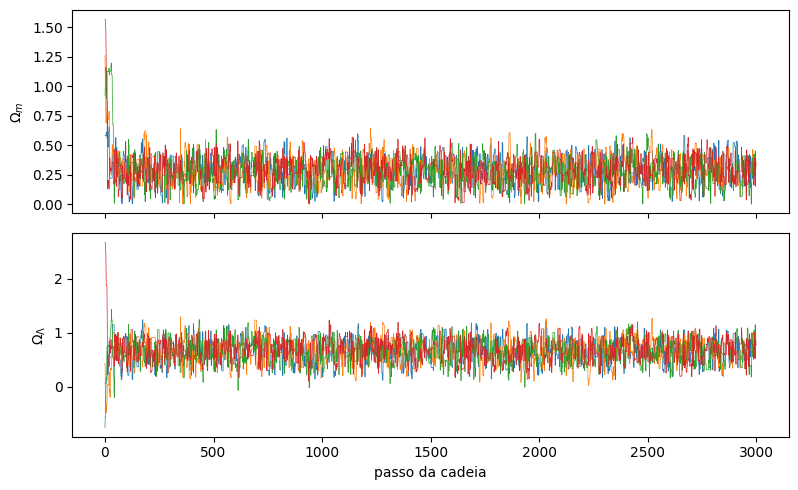

In [5]:
# o grafico mostra que tem muito pouco de burn-in
fig, eixos = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for k in range(N_cadeias):
    eixos[0].plot(cadeias[k, :3_000, 0], lw=0.5)
    eixos[1].plot(cadeias[k, :3_000, 1], lw=0.5)
eixos[0].set_ylabel(r"$\Omega_m$")
eixos[1].set_ylabel(r"$\Omega_\Lambda$")
eixos[1].set_xlabel("passo da cadeia")
plt.tight_layout(); plt.savefig(FIGURAS / "aquecimento.png", dpi=150); plt.show()

In [6]:
logp_max = logps_cadeias.max()
for k in range(N_cadeias):
    chegada = np.argmax(logps_cadeias[k] > logp_max - 5)
    print(f"cadeia {k}: chega na regiao tipica no passo {chegada}")

cutoff = 1_000
amostras = cadeias[:, cutoff:, :].reshape(-1, 2)     # junta as cadeias numa tabela so
for k in range(N_cadeias):
    print(f"cadeia {k}: media {cadeias[k, cutoff:].mean(axis=0).round(3)}")

cadeia 0: chega na regiao tipica no passo 21
cadeia 1: chega na regiao tipica no passo 26
cadeia 2: chega na regiao tipica no passo 44
cadeia 3: chega na regiao tipica no passo 11
cadeia 0: media [0.282 0.663]
cadeia 1: media [0.281 0.66 ]
cadeia 2: media [0.28  0.658]
cadeia 3: media [0.281 0.658]


## Contornos de 68% e 95%

Om: cadeia 0.2809 +- 0.1125   grade 0.2807 +- 0.1125
OL: cadeia 0.6597 +- 0.2107   grade 0.6609 +- 0.2100


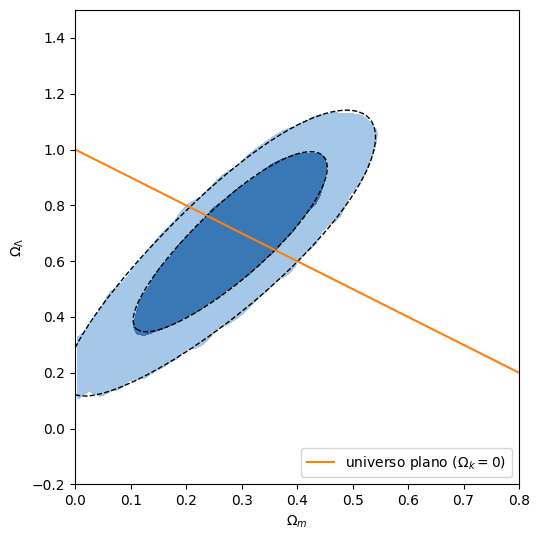

Om = 0.281 +- 0.112
OL = 0.660 +- 0.211
Ok = 0.059 +- 0.311
q0 = -0.519 +- 0.166
correlacao entre Om e OL: 0.8387623684444414
fracao das amostras com OL > 0: 0.9990969387755102
fracao das amostras com q0 < 0: 0.9985765306122449


In [7]:
om_s, ol_s = amostras[:, 0], amostras[:, 1]

  # histograma 2D suavizado das amostras
N_BINS = 80
H, bordas_om, bordas_ol = np.histogram2d(om_s, ol_s, bins=N_BINS, range=[[0.0, 0.8], [-0.2, 1.5]])
H = gaussian_filter(H, 1.0)
centros_om = (bordas_om[1:] + bordas_om[:-1]) / 2
centros_ol = (bordas_ol[1:] + bordas_ol[:-1]) / 2

# nivel de cada contorno: a densidade que deixa 68% (95%) das amostras do lado de dentro
i_om = np.clip(np.searchsorted(bordas_om, om_s) - 1, 0, N_BINS - 1)
i_ol = np.clip(np.searchsorted(bordas_ol, ol_s) - 1, 0, N_BINS - 1)
densidade_amostra = H[i_om, i_ol]
nivel_68 = np.quantile(densidade_amostra, 1 - 0.68)
nivel_95 = np.quantile(densidade_amostra, 1 - 0.95)

  # teste: a mesma posterior calculada numa grade, sem cadeia nenhuma
om_g = np.linspace(0.0, 0.8, 81)
ol_g = np.linspace(-0.2, 1.5, 86)
logp_g = np.array([[post((om, ol)) for ol in ol_g] for om in om_g])
p_g = np.exp(logp_g - logp_g.max())
peso = p_g / p_g.sum()
OM_g, OL_g = np.meshgrid(om_g, ol_g, indexing="ij")

media_om_g = (peso * OM_g).sum()
media_ol_g = (peso * OL_g).sum()
desvio_om_g = np.sqrt((peso * (OM_g - media_om_g)**2).sum())
desvio_ol_g = np.sqrt((peso * (OL_g - media_ol_g)**2).sum())
print(f"Om: cadeia {om_s.mean():.4f} +- {om_s.std():.4f}   grade {media_om_g:.4f} +- {desvio_om_g:.4f}")
print(f"OL: cadeia {ol_s.mean():.4f} +- {ol_s.std():.4f}   grade {media_ol_g:.4f} +- {desvio_ol_g:.4f}")
assert abs(om_s.mean() - media_om_g) < 0.005 and abs(ol_s.mean() - media_ol_g) < 0.005
assert abs(om_s.std() - desvio_om_g) < 0.005 and abs(ol_s.std() - desvio_ol_g) < 0.005

valores = np.sort(p_g.ravel())[::-1]
acumulada = np.cumsum(valores) / valores.sum()
nivel_68_g = valores[np.searchsorted(acumulada, 0.68)]
nivel_95_g = valores[np.searchsorted(acumulada, 0.95)]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.contourf(centros_om, centros_ol, H.T, levels=[nivel_95, nivel_68, H.max()],
              colors=["#a6c8e8", "#3a78b5"])
ax.contour(om_g, ol_g, p_g.T, levels=[nivel_95_g, nivel_68_g], colors="k", linestyles="--", linewidths=1)
ax.plot([0, 0.8], [1, 0.2], color="tab:orange", label=r"universo plano ($\Omega_k = 0$)")
ax.set_xlabel(r"$\Omega_m$")
ax.set_ylabel(r"$\Omega_\Lambda$")
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(FIGURAS / "contornos.png", dpi=150); plt.show()


omega_k_s = 1 - om_s - ol_s
q0_s = om_s / 2 - ol_s                 # parametro de desaceleracao hoje

for nome, x in [("Om", om_s), ("OL", ol_s), ("Ok", omega_k_s), ("q0", q0_s)]:
  print(f"{nome} = {x.mean():.3f} +- {x.std():.3f}")
print("correlacao entre Om e OL:", np.corrcoef(om_s, ol_s)[0, 1])
print("fracao das amostras com OL > 0:", np.mean(ol_s > 0))
print("fracao das amostras com q0 < 0:", np.mean(q0_s < 0))

## Diagnósticos de convergência

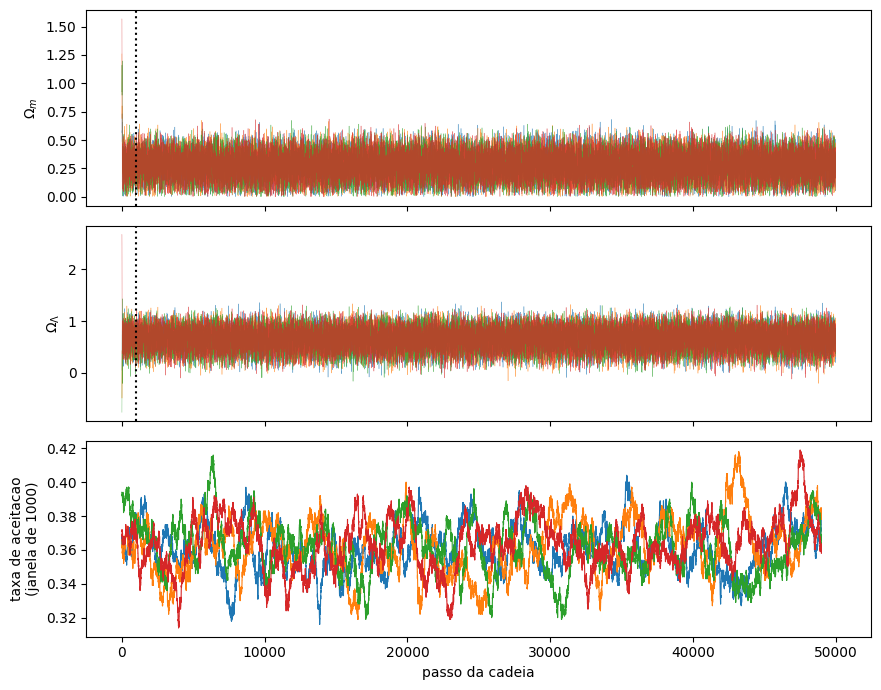

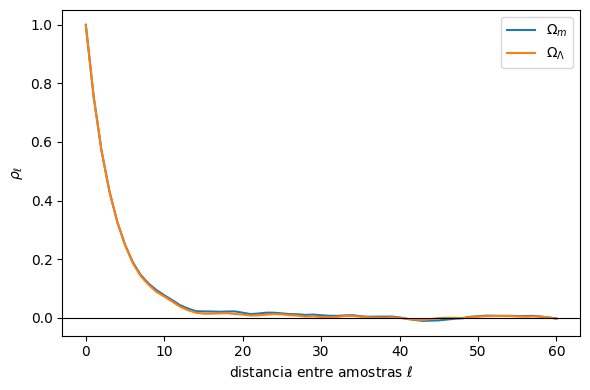

Om: tau por cadeia [7.8 6.9 7.  7.2], ESS 27178 de 196000, media 0.2809 +- MCSE 0.0007, desvio da posterior 0.1125
OL: tau por cadeia [7.5 6.9 7.2 7.4], ESS 27087 de 196000, media 0.6597 +- MCSE 0.0013, desvio da posterior 0.2107


In [8]:
nomes = [r"$\Omega_m$", r"$\Omega_\Lambda$"]

# tracos das cadeias inteiras e taxa de aceitacao ao longo delas
fig, eixos = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for k in range(N_cadeias):
    eixos[0].plot(cadeias[k, :, 0], lw=0.3, alpha=0.7)
    eixos[1].plot(cadeias[k, :, 1], lw=0.3, alpha=0.7)
    eixos[2].plot(taxa_movel(aceitos_cadeias[k]), lw=0.8)
for p in range(2):
    eixos[p].set_ylabel(nomes[p])
    eixos[p].axvline(cutoff, color="k", ls=":")
eixos[2].set_ylabel("taxa de aceitacao\n(janela de 1000)")
eixos[2].set_xlabel("passo da cadeia")
plt.tight_layout(); plt.savefig(FIGURAS / "traces.png", dpi=150); plt.show()

depois = cadeias[:, cutoff:, :]          # (N_cadeias, N_passos - cutoff, 2)

# autocorrelacao da primeira cadeia
fig, ax = plt.subplots(figsize=(6, 4))
for p in range(2):
    ax.plot(autocorrelacao(depois[0, :, p], 60), label=nomes[p])
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel(r"distancia entre amostras $\ell$")
ax.set_ylabel(r"$\rho_\ell$")
ax.legend(); plt.tight_layout(); plt.savefig(FIGURAS / "autocorrelacao.png", dpi=150); plt.show()

  # numeros
for p, nome in enumerate(["Om", "OL"]):
    x = depois[:, :, p]
    taus = [tempo_autocorrelacao(x[k]) for k in range(N_cadeias)]
    print(f"{nome}: tau por cadeia {np.round(taus, 1)}, ESS {ess(x):.0f} de {x.size}, "
        f"media {x.mean():.4f} +- MCSE {mcse(x):.4f}, desvio da posterior {x.std():.4f}")

Om: split-R-hat = 1.00020   (so os 300 primeiros passos: 1.052)


   cadeia 0: P0 = 0.1124, j* = 1574, alpha = 1.63, r = 1.8e-04, passa = True, P0/variancia = 8.8


   cadeia 1: P0 = 0.1106, j* = 1507, alpha = 1.57, r = 1.8e-04, passa = True, P0/variancia = 8.7


   cadeia 2: P0 = 0.1073, j* = 1484, alpha = 1.55, r = 1.8e-04, passa = True, P0/variancia = 8.6


   cadeia 3: P0 = 0.0945, j* = 1969, alpha = 1.76, r = 1.5e-04, passa = True, P0/variancia = 7.4


OL: split-R-hat = 1.00022   (so os 300 primeiros passos: 1.031)


   cadeia 0: P0 = 0.4029, j* = 1451, alpha = 1.57, r = 1.9e-04, passa = True, P0/variancia = 9.1


   cadeia 1: P0 = 0.4165, j* = 1401, alpha = 1.57, r = 1.9e-04, passa = True, P0/variancia = 9.2


   cadeia 2: P0 = 0.4003, j* = 1441, alpha = 1.57, r = 1.9e-04, passa = True, P0/variancia = 9.1


   cadeia 3: P0 = 0.4155, j* = 1407, alpha = 1.56, r = 1.9e-04, passa = True, P0/variancia = 9.4


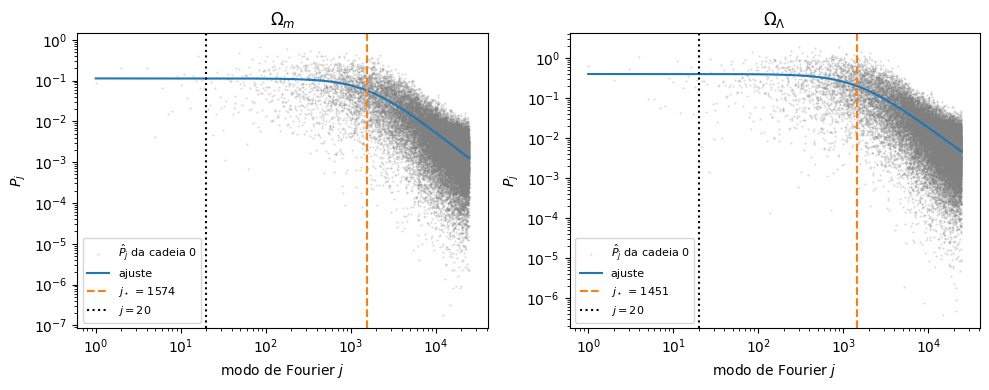

In [9]:
fig, eixos_esp = plt.subplots(1, 2, figsize=(10, 4))

for p, nome in enumerate(["Om", "OL"]):
      print(f"{nome}: split-R-hat = {split_rhat(depois[:, :, p]):.5f}"
            f"   (so os 300 primeiros passos: {split_rhat(cadeias[:, :300, p]):.3f})")
      for k in range(N_cadeias):
          res = dunkley(depois[k, :, p])
          print(f"   cadeia {k}: P0 = {res['P0']:.4f}, j* = {res['j_star']:.0f}, alpha = {res['alpha']:.2f}, "
                f"r = {res['r']:.1e}, passa = {res['passa']}, P0/variancia = {res['P0'] / np.var(depois[k, :, p]):.1f}")

      # espectro da cadeia 0 no grafico
      jj, Pj = espectro(depois[0, :, p])
      res0 = dunkley(depois[0, :, p])
      eixos_esp[p].loglog(jj, Pj, ".", ms=1, alpha=0.3, color="gray", label=r"$\hat P_j$ da cadeia 0")
      eixos_esp[p].loglog(jj, res0["P0"] / (1 + (jj / res0["j_star"])**res0["alpha"]), "C0", label="ajuste")
      eixos_esp[p].axvline(res0["j_star"], color="C1", ls="--", label=rf"$j_\star$ = {res0['j_star']:.0f}")
      eixos_esp[p].axvline(20, color="k", ls=":", label=r"$j = 20$")
      eixos_esp[p].set_xlabel("modo de Fourier $j$")
      eixos_esp[p].set_ylabel(r"$P_j$")
      eixos_esp[p].set_title(nomes[p])
      eixos_esp[p].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURAS / "dunkley.png", dpi=150); plt.show()

## Checagens das escolhas numéricas

A distância comóvel é integrada numa grade de $N = 1000$ pontos em $z$ e interpolada. Refazendo com $N = 20\,000$, a diferença em $\mu$ tem que ficar muito abaixo dos erros do catálogo.

In [10]:
rng_N = np.random.default_rng(20260916)
sorteados = []
while len(sorteados) < 300:
    candidato = (rng_N.uniform(OM_MIN, OM_MAX), rng_N.uniform(OL_MIN, OL_MAX))
    if np.isfinite(post(candidato)):
        sorteados.append(candidato)

def diferenca_mu(om, ol):
    # maior diferenca em mu entre as grades de 1000 e de 20 000 pontos, nas 580 supernovas
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.max(np.abs(FLRW(70, om, ol, N=20_000).mu(z_sn) - FLRW(70, om, ol).mu(z_sn)))

print("no melhor ajuste (0.295, 0.70):", diferenca_mu(0.295, 0.70), "mag")
print("maior diferenca em 300 cosmologias sorteadas:", max(diferenca_mu(om, ol) for om, ol in sorteados), "mag")
print("menor erro do catalogo:", sigma_mu.min(), "mag")
print("chi2 no melhor ajuste com N = 1000 e 20 000:",
      chi2_marg(FLRW(70, 0.295, 0.70).mu(z_sn)), chi2_marg(FLRW(70, 0.295, 0.70, N=20_000).mu(z_sn)))

no melhor ajuste (0.295, 0.70): 3.306343898401565e-05 mag


maior diferenca em 300 cosmologias sorteadas: 0.00017921386202601752 mag
menor erro do catalogo: 0.0841441236726 mag
chi2 no melhor ajuste com N = 1000 e 20 000: 545.1132528946443 545.1105623888063


O ponto zero $\mathcal{M}$ foi integrado analiticamente em `chi2_marg`. Como checagem, as cadeias abaixo amostram $\mathcal{M}$ como terceiro parâmetro, com priori plana em $[-1, 1]$ e o $\chi^2$ completo, sem integrar nada. Se a integral estiver certa, a posterior em $(\Omega_m, \Omega_\Lambda)$ tem que ser a mesma.

In [11]:
M_MIN, M_MAX = -1.0, 1.0

def log_likelihood_com_M(theta, model):
    omega_m, omega_lambda, M = theta
    with np.errstate(invalid="ignore", divide="ignore"):
        mu_teoria = model(H0=70, omega_m=omega_m, omega_lambda=omega_lambda).mu(z_sn)
    if not np.all(np.isfinite(mu_teoria)):
        return -np.inf
    r = solve_triangular(L_sys, mu_obs - mu_teoria - M, lower=True)   # chi2 completo, com M fixo
    return -0.5 * (r @ r)

def log_prior_com_M(theta):
    omega_m, omega_lambda, M = theta
    if not M_MIN <= M <= M_MAX:
        return -np.inf
    return log_prior((omega_m, omega_lambda))

post_M = Posterior(FLRW, log_likelihood_com_M, log_prior_com_M)

geradores_M = [np.random.default_rng(s) for s in np.random.SeedSequence(20260914).spawn(N_cadeias + 2)]

# aquecimento igual ao das cadeias principais, agora com a regra 2.38^2/3 para 3 parametros
cov_prop_M = np.diag([0.05**2, 0.05**2, 0.01**2])
theta = [0.3, 0.7, 0.0]
for rodada in range(2):
    mh = MetropolisHastings(post_M, GaussianRandomWalk(cov_prop_M))
    amostras_aq, _, _, taxa_aq = mh.sample(theta, 5_000, geradores_M[0])
    cov_prop_M = 2.38**2/3 * np.cov(amostras_aq[2_500:].T)
    theta = amostras_aq[-1]
    print(f"rodada {rodada}: taxa de aceitacao {taxa_aq:.2f}")

inicios_M = []
while len(inicios_M) < N_cadeias:
    candidato = [geradores_M[1].uniform(OM_MIN, OM_MAX), geradores_M[1].uniform(OL_MIN, OL_MAX),
                 geradores_M[1].uniform(M_MIN, M_MAX)]
    if np.isfinite(post_M(candidato)):
        inicios_M.append(candidato)
print("pontos de partida:\n", np.round(inicios_M, 2))

proposta_M = GaussianRandomWalk(cov_prop_M)
cadeias_M, logps_M = [], []
for k in range(N_cadeias):
    amostras_k, logps_k, _, taxa_k = MetropolisHastings(post_M, proposta_M).sample(
        inicios_M[k], N_passos, geradores_M[2 + k])
    cadeias_M.append(amostras_k)
    logps_M.append(logps_k)
    print(f"cadeia {k}: taxa de aceitacao {taxa_k:.3f}")
cadeias_M = np.array(cadeias_M)          # formato (N_cadeias, N_passos, 3)
logps_M = np.array(logps_M)

rodada 0: taxa de aceitacao 0.60


rodada 1: taxa de aceitacao 0.34
pontos de partida:
 [[ 0.94  0.78 -0.22]
 [ 0.92  2.09  0.99]
 [ 0.55 -0.88 -0.53]
 [ 1.    1.39 -0.34]]


cadeia 0: taxa de aceitacao 0.305


cadeia 1: taxa de aceitacao 0.303


cadeia 2: taxa de aceitacao 0.300


cadeia 3: taxa de aceitacao 0.301


cadeia 0: chega na regiao tipica no passo 31
cadeia 1: chega na regiao tipica no passo 133
cadeia 2: chega na regiao tipica no passo 126
cadeia 3: chega na regiao tipica no passo 39
Om = 0.2797 +- 0.1118   split-R-hat 1.00002   ESS 16480


OL = 0.6595 +- 0.2091   split-R-hat 1.00011   ESS 17268


M = 0.0147 +- 0.0329   split-R-hat 1.00030   ESS 19286
(M integrado: Om = 0.2809 +- 0.1125   OL = 0.6597 +- 0.2107)
M integrado: 0.679 dentro do contorno de 68%, 0.949 dentro do de 95%
M amostrado: 0.683 dentro do contorno de 68%, 0.950 dentro do de 95%


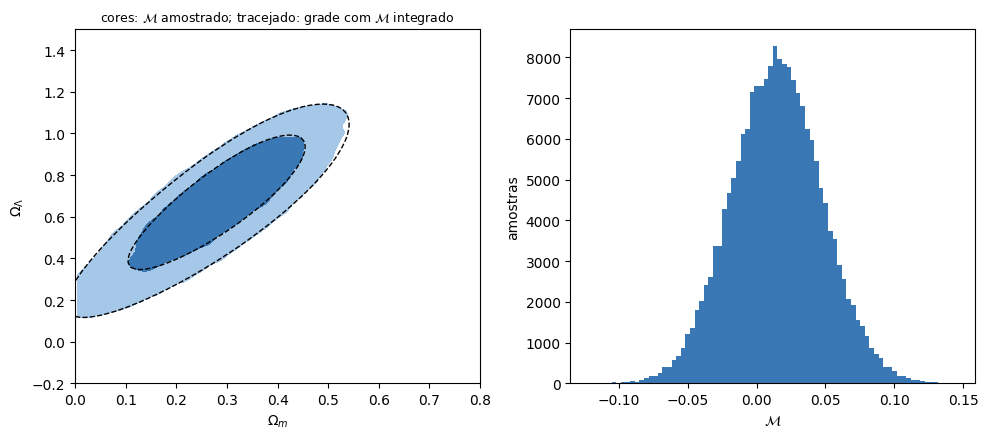

In [12]:
for k in range(N_cadeias):
    print(f"cadeia {k}: chega na regiao tipica no passo {np.argmax(logps_M[k] > logps_M.max() - 5)}")

depois_M = cadeias_M[:, cutoff:, :]
for p, nome in enumerate(["Om", "OL", "M"]):
    x = depois_M[:, :, p]
    print(f"{nome} = {x.mean():.4f} +- {x.std():.4f}   split-R-hat {split_rhat(x):.5f}   ESS {ess(x):.0f}")
print(f"(M integrado: Om = {om_s.mean():.4f} +- {om_s.std():.4f}   OL = {ol_s.mean():.4f} +- {ol_s.std():.4f})")

# fracao das amostras dentro dos contornos de 68% e 95% da grade, que usa o M integrado
densidade_grade = RegularGridInterpolator((om_g, ol_g), p_g, bounds_error=False, fill_value=0.0)
amostras_M = depois_M[:, :, :2].reshape(-1, 2)
for nome, pontos in [("M integrado", amostras), ("M amostrado", amostras_M)]:
    d = densidade_grade(pontos)
    print(f"{nome}: {np.mean(d >= nivel_68_g):.3f} dentro do contorno de 68%, "
          f"{np.mean(d >= nivel_95_g):.3f} dentro do de 95%")

  # mesmos contornos da celula anterior, agora com as amostras de M amostrado
H_M, _, _ = np.histogram2d(amostras_M[:, 0], amostras_M[:, 1], bins=N_BINS, range=[[0.0, 0.8], [-0.2, 1.5]])
H_M = gaussian_filter(H_M, 1.0)
i_om = np.clip(np.searchsorted(bordas_om, amostras_M[:, 0]) - 1, 0, N_BINS - 1)
i_ol = np.clip(np.searchsorted(bordas_ol, amostras_M[:, 1]) - 1, 0, N_BINS - 1)
nivel_68_M = np.quantile(H_M[i_om, i_ol], 1 - 0.68)
nivel_95_M = np.quantile(H_M[i_om, i_ol], 1 - 0.95)

fig, (ax, ax_M) = plt.subplots(1, 2, figsize=(10, 4.5))
ax.contourf(centros_om, centros_ol, H_M.T, levels=[nivel_95_M, nivel_68_M, H_M.max()],
            colors=["#a6c8e8", "#3a78b5"])
ax.contour(om_g, ol_g, p_g.T, levels=[nivel_95_g, nivel_68_g], colors="k", linestyles="--", linewidths=1)
ax.set_xlabel(r"$\Omega_m$")
ax.set_ylabel(r"$\Omega_\Lambda$")
ax.set_title(r"cores: $\mathcal{M}$ amostrado; tracejado: grade com $\mathcal{M}$ integrado", fontsize=9)
ax_M.hist(depois_M[:, :, 2].ravel(), bins=80, color="#3a78b5")
ax_M.set_xlabel(r"$\mathcal{M}$")
ax_M.set_ylabel("amostras")
plt.tight_layout(); plt.savefig(FIGURAS / "contornos_M.png", dpi=150); plt.show()